<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/m3_c1_cleaning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 - Class 1: Data Cleaning Lab

**Dataset:** Telco Customer Churn  
**Objective:** Learn to inspect, clean, and prepare raw data for modeling.

### What you will practice
- Inspecting data structure and types
- Detecting and fixing type conversion issues
- Handling missing values (mean, median, mode imputation)
- Checking for inconsistent categorical entries
- Outlier detection with IQR and Z-score methods

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


## 1. Load Data

We load the Telco Customer Churn dataset. If the URL doesn't work, use the upload fallback cell below.

In [2]:
# Primary: load from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fallback: upload from local machine (uncomment if URL fails)
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# df = pd.read_csv(filename)
# print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")

## 2. Inspect Structure

In [4]:
# Shape
print("Shape:", df.shape)
print()

Shape: (7043, 21)



In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Statistical summary for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Statistical summary for categorical columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Fix the TotalCharges Type Issue

Notice that `TotalCharges` shows up as `object` (string) even though it should be numeric. Let's investigate and fix this.

In [8]:
# Check the dtype
print("TotalCharges dtype:", df['TotalCharges'].dtype)

# Try converting - this will show us the problem rows
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print(f"\nRows that can't be converted to numeric: {mask.sum()}")
print("\nProblematic values:")
df.loc[mask, ['customerID', 'TotalCharges', 'tenure', 'MonthlyCharges']]

TotalCharges dtype: object

Rows that can't be converted to numeric: 11

Problematic values:


,customerID,TotalCharges,tenure,MonthlyCharges
488,4472-LVYGI,,0,52.55
753,3115-CZMZD,,0,20.25
936,5709-LVOEQ,,0,80.85
1082,4367-NUYAO,,0,25.75
1340,1371-DWPAZ,,0,56.05
3331,7644-OMVMY,,0,19.85
3826,3213-VVOLG,,0,25.35
4380,2520-SGTTA,,0,20.00
5218,2923-ARZLG,,0,19.70
6670,4075-WKNIU,,0,73.35


In [9]:
# These are customers with tenure=0 (new customers) where TotalCharges is a blank string.
# Fix: convert to numeric, blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)
print(f"NaN count in TotalCharges: {df['TotalCharges'].isna().sum()}")

TotalCharges dtype after fix: float64
NaN count in TotalCharges: 11


In [10]:
# For new customers (tenure=0), TotalCharges should logically be 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"NaN count after fill: {df['TotalCharges'].isna().sum()}")

NaN count after fill: 0


## 4. Missing Values

### 4a. Check for missing values across all columns

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df[missing_df['count'] > 0]

,count,percent


### 4b. Demonstrate imputation methods

We'll create artificial missing values in `MonthlyCharges` to practice different imputation strategies.

In [12]:
# Create a copy and inject random NaNs for demonstration
np.random.seed(42)
df_demo = df.copy()
nan_idx = np.random.choice(df_demo.index, size=200, replace=False)
df_demo.loc[nan_idx, 'MonthlyCharges'] = np.nan
print(f"Injected {df_demo['MonthlyCharges'].isna().sum()} NaN values into MonthlyCharges")

Injected 200 NaN values into MonthlyCharges


In [13]:
# Mean imputation
mean_val = df_demo['MonthlyCharges'].mean()
df_mean = df_demo.copy()
df_mean['MonthlyCharges'] = df_mean['MonthlyCharges'].fillna(mean_val)
print(f"Mean imputation value: {mean_val:.2f}")
print(f"Remaining NaN: {df_mean['MonthlyCharges'].isna().sum()}")

Mean imputation value: 64.74
Remaining NaN: 0


In [14]:
# Median imputation
median_val = df_demo['MonthlyCharges'].median()
df_median = df_demo.copy()
df_median['MonthlyCharges'] = df_median['MonthlyCharges'].fillna(median_val)
print(f"Median imputation value: {median_val:.2f}")
print(f"Remaining NaN: {df_median['MonthlyCharges'].isna().sum()}")

Median imputation value: 70.30
Remaining NaN: 0


### 4c. TODO: Mode Imputation + Missing Indicator

Complete the two tasks below.

In [15]:
# TODO 1: Perform mode imputation on df_demo['MonthlyCharges']
# Hint: use df_demo['MonthlyCharges'].mode()[0]
# Store the result in df_mode

df_mode = df_demo.copy()
# YOUR CODE HERE


# TODO 2: Create a binary missing indicator column called 'MonthlyCharges_missing'
# It should be 1 where MonthlyCharges was NaN, 0 otherwise
# Add it to df_mode BEFORE filling NaN values

# YOUR CODE HERE


## 5. Inconsistent Entries

Check categorical columns for inconsistent or unexpected values.

In [16]:
# Check unique values for key categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # skip ID

for col in cat_cols:
    vc = df[col].value_counts()
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(vc)
    print()

--- gender (2 unique) ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner (2 unique) ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents (2 unique) ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService (2 unique) ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines (3 unique) ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService (3 unique) ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity (3 unique) ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup (3 unique) ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection (3 unique) -

In [17]:
# Notice: some columns have 'No internet service' and 'No phone service'
# which could be simplified to 'No' depending on your modeling choice.
# Let's check which columns have these:

for col in cat_cols:
    vals = df[col].unique()
    special = [v for v in vals if 'No ' in str(v) and v != 'No']
    if special:
        print(f"{col}: {special}")

MultipleLines: ['No phone service']
OnlineSecurity: ['No internet service']
OnlineBackup: ['No internet service']
DeviceProtection: ['No internet service']
TechSupport: ['No internet service']
StreamingTV: ['No internet service']
StreamingMovies: ['No internet service']


In [18]:
# Standardize: replace verbose 'No X service' with 'No'
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in replace_cols:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print("Standardization complete.")
print("OnlineSecurity values:", df['OnlineSecurity'].unique())

Standardization complete.
OnlineSecurity values: ['No' 'Yes']


## 6. Outlier Detection

### 6a. IQR Method (demonstrated)

In [19]:
def detect_outliers_iqr(series, factor=1.5):
    """Detect outliers using the IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = (series < lower) | (series > upper)
    return outliers, lower, upper

# Apply to MonthlyCharges and TotalCharges
for col in ['MonthlyCharges', 'TotalCharges', 'tenure']:
    outliers, lower, upper = detect_outliers_iqr(df[col])
    print(f"{col}: {outliers.sum()} outliers (bounds: [{lower:.2f}, {upper:.2f}])")

MonthlyCharges: 0 outliers (bounds: [-46.02, 171.38])
TotalCharges: 0 outliers (bounds: [-4683.52, 8868.67])
tenure: 0 outliers (bounds: [-60.00, 124.00])


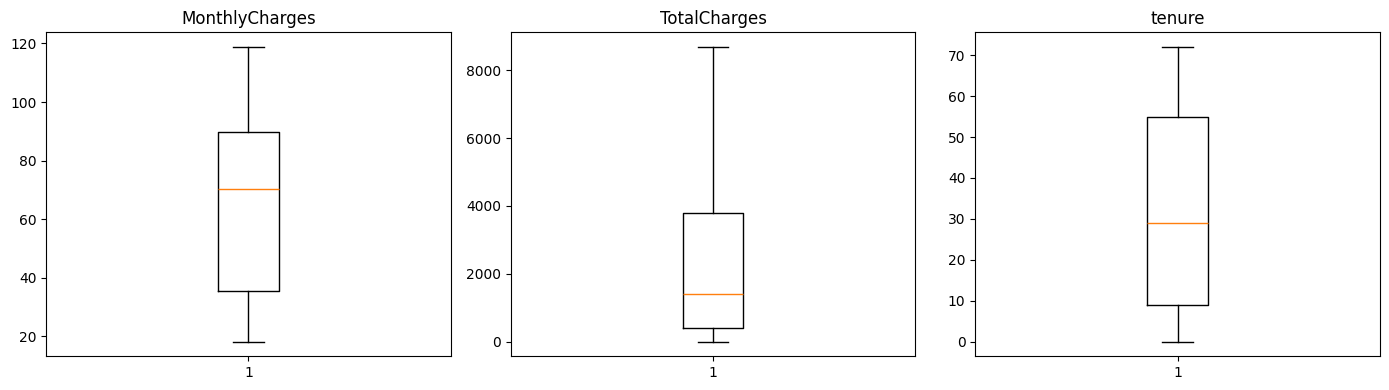

In [20]:
# Visualize distributions with box plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['MonthlyCharges', 'TotalCharges', 'tenure']):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 6b. TODO: Z-score Method

Implement outlier detection using Z-scores. A data point is an outlier if its Z-score exceeds a threshold (typically 3).

In [21]:
# TODO: Implement Z-score outlier detection
#
# Z-score formula: z = (x - mean) / std
# A point is an outlier if |z| > threshold
#
# 1. Write a function detect_outliers_zscore(series, threshold=3)
#    that returns a boolean mask of outliers
# 2. Apply it to 'MonthlyCharges', 'TotalCharges', 'tenure'
# 3. Print how many outliers each column has
# 4. Compare results with IQR method above

def detect_outliers_zscore(series, threshold=3):
    # YOUR CODE HERE
    pass

# YOUR CODE HERE - apply and print results


## 7. Save Cleaned Data

In [22]:
# Final check
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum(), "total")
print("\nDtypes:")
print(df.dtypes.value_counts())

Shape: (7043, 21)

Missing values:
0 total

Dtypes:
object     17
int64       2
float64     2
Name: count, dtype: int64


In [23]:
# Save to CSV
df.to_csv('telco_churn_cleaned.csv', index=False)
print("Saved: telco_churn_cleaned.csv")

# Download in Colab
# from google.colab import files
# files.download('telco_churn_cleaned.csv')

Saved: telco_churn_cleaned.csv


---
## Summary

| Step | What we did |
|------|-------------|
| Inspect | `.info()`, `.describe()`, `.shape` |
| Type fix | `TotalCharges` string to numeric |
| Missing values | Mean/median imputation (TODO: mode + indicator) |
| Inconsistencies | Standardized 'No X service' values |
| Outliers | IQR method (TODO: Z-score) |